# Task 

Our company is not working efficiently, as it spends too much time drafting documents.

For the company, we need to create an AI Agentic System that can `speed up drafting documents, emails, etc`. The Agentic System should have `Human-AI collaboration` meaning the Human should be able to provide `continuous feedback` and the AI agent should stop when Human is happy with the draft.

The system must `be fast and be able to save the drafts`.

## Local Model with LM Studio

In this notebook, we use **LM Studio** to run a local LLM instead of calling OpenAI's API. LM Studio provides an OpenAI-compatible API at `http://localhost:1234/v1`, which allows us to use the same `ChatOpenAI` interface but pointing to our local server.

**Requirements:**
- Have LM Studio running with a model loaded
- The local server should be started (default port: 1234)

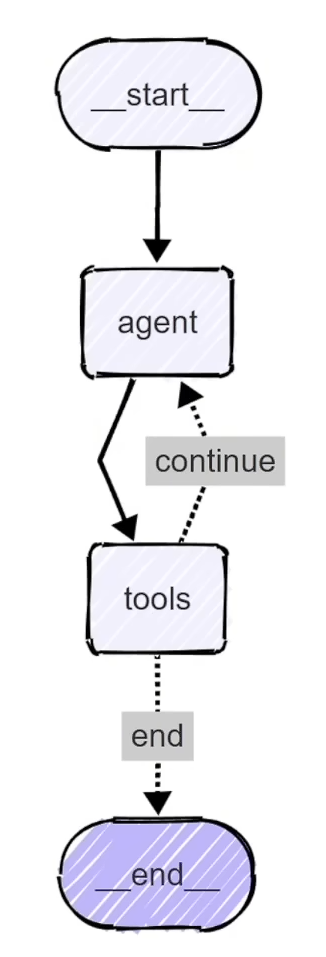

In [ ]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI  # Still used but pointing to LM Studio local server
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# Note: No need for API keys when using LM Studio local server

In [ ]:
# This is the global variable to store document content
document_content = ""

class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage], add_messages]

@tool
def update(content : str) -> str:
    """
    Updates the document with the provided content
    """

    global document_content
    document_content = content

    return f"Document has been updated succesfully! The content is {document_content}"

@tool
def save(filename: str) -> str:
    """
    Save the current document to a text file and finish the process.

    Args:
        filename: name for the text file
    """
    if not filename.endswith(".txt"):
        filename = f"{filename}.txt"

    try:
        with open(filename, "w") as file:
            file.write(document_content)
        print(f" Document has been saved to: {filename}")

    except Exception as e:
        return f" Error saving document: {str(e)}"
    
tools = [update, save]

# Using LM Studio local server instead of OpenAI API
# Make sure LM Studio is running with a model loaded and the server is started
model = ChatOpenAI(
    base_url="http://localhost:1234/v1",  # LM Studio local server
    api_key="lm-studio",  # LM Studio doesn't require a real API key
    model="local-model",  # LM Studio uses the currently loaded model
    temperature=0.7
).bind_tools(tools)

In [ ]:
def our_agent(state : AgentState) -> AgentState:
    system_prompt = SystemMessage(
        content = f"""

        You are a Drafter, a helpful writing assistant. You are going to help the user update and modify documents.

        - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
        - If the user wants to save and finish, you need to use the 'save' tool.
        - Make sure to always show the current document state after modifications.

        The current document content is {document_content}

        """
    )

    if not state["messages"]:
        user_input = "I'm ready to help you update the document. What do you like to create? "
        user_message = HumanMessage(content = user_input)

    else:
        user_input = input("What would you like to do with this document? ")
        print(f"USER: {user_input}")
        user_message = HumanMessage(content = user_input)

    all_messages = [system_prompt] + list(state["messages"] + [user_message])

    response = model.invoke(all_messages)

    print(f"AI: {response.content}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc["name"] for tc in response.tool_calls]}")

    return {"messages" : list(state["messages"] + [user_message, response])}

In [ ]:
def should_continue(state : AgentState) -> str:
    """
    Determine if we should continue or end the conversation
    """

    messages = state["messages"]

    if not messages:
        return "continue"
    
    # This looks for the most recent tool message
    for message in reversed(message):
        if (isinstance(message, ToolMessage) and 
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            return "end" # goes to the end edge which leads to the endpoint
        
    return "continue"


def print_messages(messages):
    """
    Function I made to print the messages in a more readable format
    """
    if not messages:
        return
    
    for message in messages[-3]:
        if isinstance(message, ToolMessage):
            print(f" TOOL RESULT: {message.content}")

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("agent", our_agent)
graph.add_node("tools", ToolNode(tools))

graph.set_entry_point("agent")
graph.add_edge("agent", "tools")


graph.add_conditional_edges(
    "tools",

    should_continue,
    {
        "continue" : "agent",
        "end" : END,
    }
)

app = graph.compile()


In [ ]:
def run_document_agent():
    print("DRAFTER")

    state = {"messages" : []}

    for step in app.stream(state, stream_mode= "values"):
        if "messages" in step:
            print_messages(step["messages"])


    print("DRAFTER FINISHED")

